[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/leoe21/machine_learning_fundamentals/blob/main/01_unidad/01_03_EDA_Churn_Guia.ipynb)


# Guía de análisis exploratorio — Telco Customer Churn

Este notebook desarrolla **cómo se estructura un EDA** en un caso de negocio (abandono de clientes en telecomunicaciones): calidad de datos, variable objetivo, exploración univariada y bivariada, apoyo estadístico, correlaciones y síntesis. El flujo es reproducible sobre el mismo dataset o adaptable a otros conjuntos tabulares similares.

**Metodología (marco):**

1. Entendimiento del dominio y diccionario de datos.
2. Calidad: duplicados, integridad, tipos, valores faltantes y códigos implícitos.
3. Univariado: forma de distribuciones (sesgo, colas), cardinalidad categórica.
4. Objetivo: prevalencia de churn y desbalance.
5. Bivariado / multivariado: asociación con el target (tablas, gráficos, Chi², comparación de medianas).
6. Correlación entre numéricas (multicolinealidad superficial).
7. Transformaciones y features (propuestas documentadas).
8. Conclusiones + límites + roadmap (modelado, métricas de negocio).

Las celdas están pensadas para ejecutarse en secuencia (**Run All**) con las dependencias instaladas y `kagglehub` configurado con credenciales Kaggle.


## Configuración e imports

- **`pandas` / `numpy`:** tablas y operaciones vectorizadas.
- **`matplotlib` / `seaborn`:** gráficos exploratorios.
- **`scipy.stats`:** pruebas de asociación (Chi², Mann–Whitney) con criterio estadístico explícito.
- **`kagglehub`:** descarga reproducible del CSV desde Kaggle.
- **`IPython.display`:** tablas con mejor formato en el notebook.

Se fija semilla (`RANDOM_STATE`) para muestreos futuros y se amplían columnas visibles en pandas para tablas anchas.


In [20]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, mannwhitneyu

import kagglehub
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 200)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titlesize"] = 12

## 1. Carga de datos

Dataset público estándar Telco (Kaggle). El archivo principal suele llamarse `WA_Fn-UseC_-Telco-Customer-Churn.csv`.

**Qué comprobar al ejecutar la celda siguiente:** que la descarga termina sin error y que `df.head()` muestra columnas como `tenure`, `MonthlyCharges`, `TotalCharges` y `Churn`. En el archivo estándar aparecen **7043 filas** y **21 columnas** (un cliente por fila).


In [21]:
path = kagglehub.dataset_download("palashfendarkar/wa-fnusec-telcocustomerchurn")
print("Ruta descargada:", path)

csv_files = sorted(Path(path).glob("*.csv"))
assert csv_files, "No se encontró CSV"
csv_path = csv_files[0]
print("Archivo:", csv_path.name)

df = pd.read_csv(csv_path)
df.head(3)

Ruta descargada: C:\Users\Usuario\.cache\kagglehub\datasets\palashfendarkar\wa-fnusec-telcocustomerchurn\versions\1
Archivo: WA_Fn-UseC_-Telco-Customer-Churn.csv


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


### Diccionario operativo (referencia rápida)

| Variable | Tipo esperado | Notas |
|----------|----------------|-------|
| `customerID` | ID | Excluir del modelado; comprobar unicidad |
| `gender`, `Partner`, `Dependents`, `PhoneService`, `PaperlessBilling` | Binaria categórica | Valores Yes/No |
| `SeniorCitizen` | 0/1 | Ya numérica |
| `tenure` | entero | Meses de antigüedad |
| `MonthlyCharges`, `TotalCharges` | continua | `TotalCharges` a veces object por vacíos |
| Servicios (`OnlineSecurity`, `TechSupport`, …) | categórica | Incluye "No internet service" como categoría informativa |
| `Contract`, `PaymentMethod`, `InternetService` | categórica | Alta interpretabilidad de negocio |
| `Churn` | objetivo | Yes / No |

**Cómo leer la tabla:** los valores `No internet service` en variables de add-on **no son ausentes**: indican que el cliente no tiene internet y por tanto ese servicio no aplica.


## 2. Auditoría de calidad e integridad

Dimensiones, tipos, memoria, **duplicados** en `customerID`, y primer inventario de problemas.

### Interpretación (dataset estándar Telco)

- **Shape (7043, 21):** volumen suficiente para EDA y para entrenar modelos tabulares sencillos.
- **Memoria:** del orden de unos pocos MB con `memory_usage(deep=True)` (el valor exacto depende del entorno).
- **Duplicados en `customerID`:** en el CSV habitual es **0**; los IDs deben ser únicos por cliente.
- **`TotalCharges` como `object`:** aunque `info()` muestra 7043 valores no nulos, parte de ellos son **cadenas vacías**; por eso el conteo de `isna()` en el siguiente bloque suele dar **cero** hasta que no se convierta el tipo.


In [22]:
print("Shape:", df.shape)
print("Memoria (MB):", df.memory_usage(deep=True).sum() / 1024**2)
dup_id = df["customerID"].duplicated().sum()
print("Duplicados en customerID:", dup_id)
df.info()

Shape: (7043, 21)
Memoria (MB): 6.820952415466309
Duplicados en customerID: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract   

In [23]:
# Faltantes explícitos por columna (ordenados)
na_pct = (df.isna().mean() * 100).sort_values(ascending=False)
na_pct[na_pct > 0]

Series([], dtype: float64)

**Faltantes explícitos (`df.isna()`):** en muchas ejecuciones la serie de porcentajes sale **vacía**: no hay `NaN` “nativos” porque los huecos de `TotalCharges` vienen como texto vacío. La coerción numérica en la sección 3 transforma esos casos en `NaN` reales y permite contarlos y tratarlos.


## 3. Limpieza y transformaciones base

1. Convertir `TotalCharges` a numérico con `errors='coerce'`.
2. Identificar filas afectadas: en el dataset estándar suelen ser **11** filas con `tenure = 0` y total ausente.
3. **Política aquí:** eliminar esas filas (alternativa: imputar, p. ej. `TotalCharges = MonthlyCharges` si `tenure = 0`).
4. Trabajar sobre `data` como copia de trabajo.

### Qué deberías observar al ejecutar

- Mensaje **"Filas con TotalCharges inválido/ausente: 11"** (u otro número si el CSV difiere).
- Tabla de esas filas: siempre con **`tenure = 0`**.
- **Shape final** cercano a **(7032, 21)** = 7043 − 11.
- En `info()`, `TotalCharges` como `float64` y `Churn` como `category` para ordenar factores en gráficos.


In [24]:
data = df.copy()
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")

mask_bad = data["TotalCharges"].isna()
print("Filas con TotalCharges inválido/ausente:", mask_bad.sum())
display(data.loc[mask_bad, ["tenure", "MonthlyCharges", "TotalCharges", "Churn"]].head(10))

data = data.loc[~mask_bad].copy()
print("Shape tras limpieza:", data.shape)

Filas con TotalCharges inválido/ausente: 11


,tenure,MonthlyCharges,TotalCharges,Churn
488,0,52.55,NaN,No
753,0,20.25,NaN,No
936,0,80.85,NaN,No
1082,0,25.75,NaN,No
1340,0,56.05,NaN,No
3331,0,19.85,NaN,No
3826,0,25.35,NaN,No
4380,0,20.00,NaN,No
5218,0,19.70,NaN,No
6670,0,73.35,NaN,No


Shape tras limpieza: (7032, 21)


### Interpretación

Las filas problemáticas son **alta de cliente sin historial acumulado** (`tenure = 0`). Eliminarlas evita sesgos en ratios tipo `TotalCharges / tenure`. Si el negocio prefiere **conservar** esas filas, una regla defendible es imputar el total con el primer mes de facturación (`MonthlyCharges`) o con la mediana condicional.


In [25]:
# Tipos finales coherentes para análisis
data["SeniorCitizen"] = data["SeniorCitizen"].astype(int)
data["Churn"] = data["Churn"].astype("category")
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   customerID        7032 non-null   object  
 1   gender            7032 non-null   object  
 2   SeniorCitizen     7032 non-null   int32   
 3   Partner           7032 non-null   object  
 4   Dependents        7032 non-null   object  
 5   tenure            7032 non-null   int64   
 6   PhoneService      7032 non-null   object  
 7   MultipleLines     7032 non-null   object  
 8   InternetService   7032 non-null   object  
 9   OnlineSecurity    7032 non-null   object  
 10  OnlineBackup      7032 non-null   object  
 11  DeviceProtection  7032 non-null   object  
 12  TechSupport       7032 non-null   object  
 13  StreamingTV       7032 non-null   object  
 14  StreamingMovies   7032 non-null   object  
 15  Contract          7032 non-null   object  
 16  PaperlessBilling  7032 non-nu

## 4. Variable objetivo: prevalencia y desbalance

Para modelos de clasificación, la proporción de `Yes` define la **línea base** (un modelo que siempre predice “No” tendría accuracy ≈ proporción de la clase mayoritaria) y guía métricas (F1, recall del churn, costes asimétricos).

### Interpretación (valores típicos tras la limpieza)

- Recuentos del orden de **5163** `No` y **1869** `Yes` (aprox. **73%** / **27%**).
- **Ratio minoría/mayoría** ≈ **0,36**: hay desbalance pero no extremo; aun así conviene usar métricas más allá del accuracy y, en producción, ponderar el coste de perder un churn (falso negativo).


Churn
No     5163
Yes    1869
Name: count, dtype: int64

Proporciones:
Churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64

Ratio minoría/mayoría: 0.362


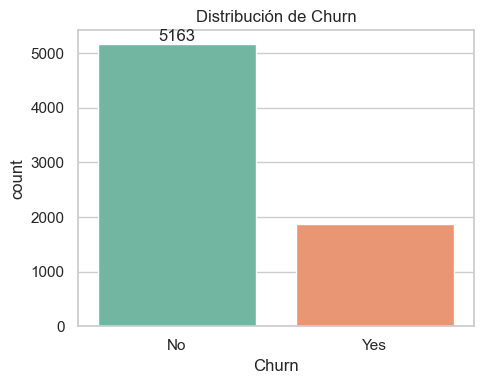

In [26]:
vc = data["Churn"].value_counts()
prop = data["Churn"].value_counts(normalize=True)
print(vc)
print("\nProporciones:")
print((prop * 100).round(2))
imbalance_ratio = vc.min() / vc.max()
print(f"\nRatio minoría/mayoría: {imbalance_ratio:.3f}")

fig, ax = plt.subplots(figsize=(5, 4))
order = ["No", "Yes"]
sns.countplot(data=data, x="Churn", order=order, ax=ax, palette="Set2")
ax.bar_label(ax.containers[0])
ax.set_title("Distribución de Churn")
plt.tight_layout()
plt.show()

## 5. Análisis univariado — variables numéricas

Estadísticos descriptivos, asimetría y curtosis. La regla **IQR** para outliers es solo una *señal estadística*, no una decisión de negocio sin contexto.

### Interpretación

- **`tenure`:** suele mostrar asimetría positiva (muchos clientes con pocos meses y una cola de clientes muy antiguos).
- **`MonthlyCharges`:** distribución con varios modos (paquetes distintos).
- **`TotalCharges`:** correlacionado con antigüedad y nivel de tarifa; tras limpieza es numérico continuo.
- **Outliers IQR:** números altos en una variable no implican error de captura; pueden ser clientes de alto ARPU.


In [27]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
desc_num = data[num_cols].describe().T
desc_num["skew"] = data[num_cols].skew()
desc_num["kurtosis"] = data[num_cols].kurtosis()
desc_num

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
tenure,7032.0,32.421786,24.545260,1.00,9.0000,29.000,55.0000,72.00,0.237731,-1.387823
MonthlyCharges,7032.0,64.798208,30.085974,18.25,35.5875,70.350,89.8625,118.75,-0.222103,-1.256156
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.4500,1397.475,3794.7375,8684.80,0.961642,-0.231799


In [28]:
def iqr_outlier_counts(s: pd.Series, k=1.5):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - k * iqr, q3 + k * iqr
    return int((s < lo).sum() + (s > hi).sum()), lo, hi

for c in num_cols:
    n, lo, hi = iqr_outlier_counts(data[c])
    print(f"{c}: outliers IQR (aprox) = {n}, límites [{lo:.2f}, {hi:.2f}]")

tenure: outliers IQR (aprox) = 0, límites [-60.00, 124.00]
MonthlyCharges: outliers IQR (aprox) = 0, límites [-45.82, 171.27]
TotalCharges: outliers IQR (aprox) = 0, límites [-4688.48, 8884.67]


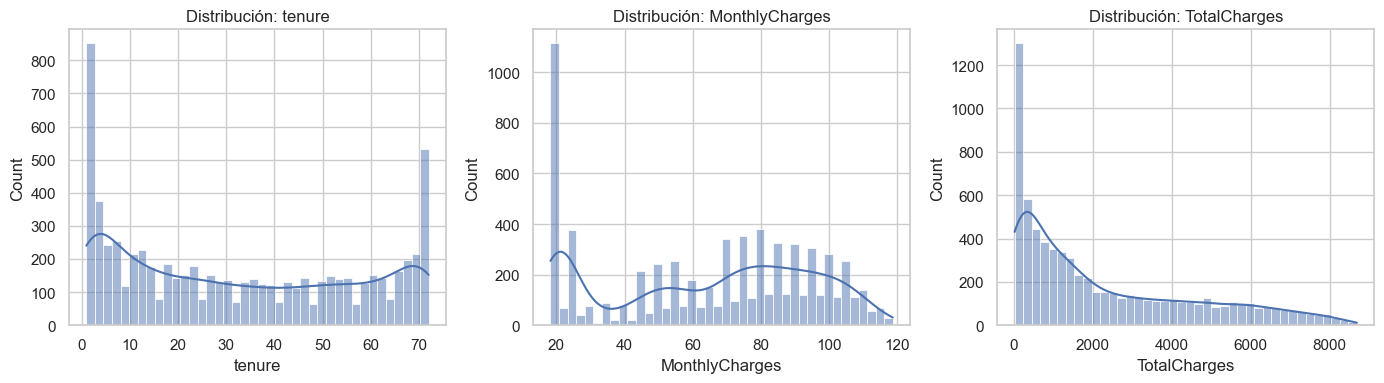

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, c in zip(axes, num_cols):
    sns.histplot(data=data, x=c, kde=True, ax=ax, bins=40)
    ax.set_title(f"Distribución: {c}")
plt.tight_layout()
plt.show()

## 6. Análisis univariado — variables categóricas

Cardinalidad baja en la mayoría de columnas; `PaymentMethod` y servicios de internet concentran la variabilidad relevante para segmentación.

Las tablas de frecuencias relativas se complementan con **gráficos de barras** (celda siguiente) para ver el peso de cada categoría.

### Interpretación

- Contratos **Month-to-month** suelen ser la categoría más frecuente (flexibilidad del cliente).
- Métodos de pago electrónicos (p. ej. *Electronic check*) suelen aparecer con frecuencia notable; es útil cruzarlos después con churn.


In [30]:
cat_cols = data.select_dtypes(include=["object"]).columns.drop("customerID", errors="ignore")
print("Número de columnas categóricas (object):", len(cat_cols))
pd.Series({c: data[c].nunique() for c in cat_cols}).sort_values(ascending=False)

Número de columnas categóricas (object): 15


PaymentMethod       4
MultipleLines       3
InternetService     3
OnlineSecurity      3
OnlineBackup        3
DeviceProtection    3
TechSupport         3
StreamingTV         3
StreamingMovies     3
Contract            3
gender              2
Partner             2
Dependents          2
PhoneService        2
PaperlessBilling    2
dtype: int64

In [31]:
for c in ["Contract", "PaymentMethod", "InternetService"]:
    print("\n", c)
    print(data[c].value_counts(normalize=True).mul(100).round(1).astype(str) + "%")


 Contract
Contract
Month-to-month    55.1%
Two year          24.0%
One year          20.9%
Name: proportion, dtype: object

 PaymentMethod
PaymentMethod
Electronic check             33.6%
Mailed check                 22.8%
Bank transfer (automatic)    21.9%
Credit card (automatic)      21.6%
Name: proportion, dtype: object

 InternetService
InternetService
Fiber optic    44.0%
DSL            34.4%
No             21.6%
Name: proportion, dtype: object


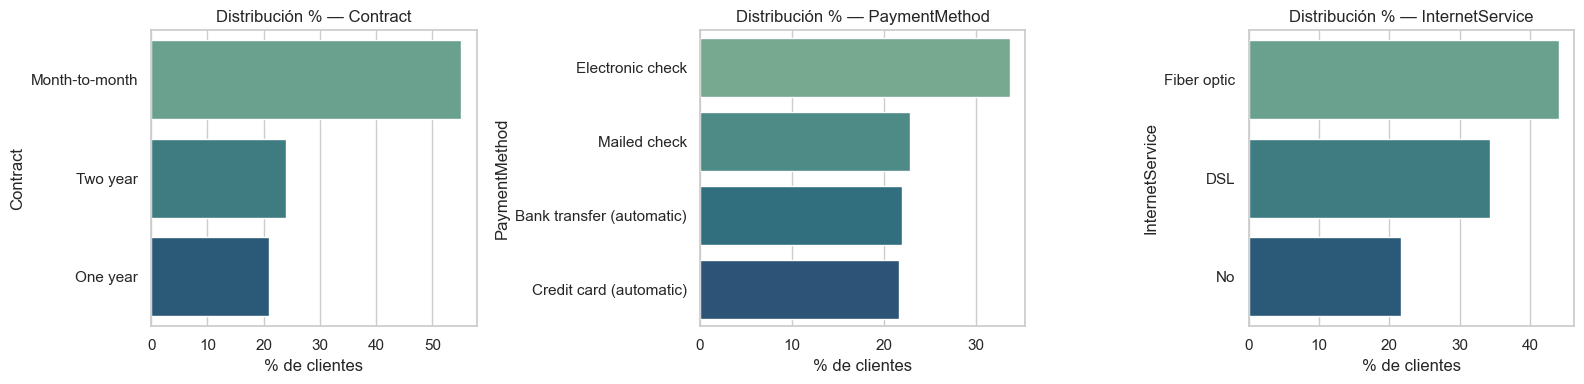

In [32]:
# Frecuencias relativas (%) de categorías clave para negocio
key_cat = ["Contract", "PaymentMethod", "InternetService"]
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, key_cat):
    vc = data[col].value_counts(normalize=True).mul(100).sort_values(ascending=False)
    sns.barplot(x=vc.values, y=vc.index.astype(str), ax=ax, palette="crest")
    ax.set_title(f"Distribución % — {col}")
    ax.set_xlabel("% de clientes")
plt.tight_layout()
plt.show()


## 7. Asociación categórica ↔ Churn (Chi-cuadrado)

Para cada variable categórica se construye una tabla de contingencia `Churn × variable` y un test **χ²** de independencia. Un **p-valor bajo** (típicamente < 0,05) sugiere que la distribución del churn **no es independiente** de esa variable (asociación estadística). El **tamaño del efecto** debe leerse en las **proporciones** y gráficos, no solo en el p-valor.

### Interpretación típica en este dataset

- Variables como **`Contract`**, **`InternetService`** y add-ons de seguridad suelen tener **p-valores muy pequeños** (asociación fuerte con el churn en la muestra).
- Variables como **`gender`** a menudo muestran **p-valor alto**: en esta muestra el churn no difiere de forma significativa entre hombres y mujeres (no implica ausencia de sesgo en otros contextos).

Las tablas de **tasa de churn (%)** por categoría permiten traducir el hallazgo a negocio (p. ej. contrato mes a mes con mayor % de abandono). Tras el bloque de tablas numéricas, un **gráfico de barras** resume las mismas tasas para lectura comparativa rápida.


In [33]:
chi_rows = []
for c in cat_cols:
    if c == "Churn":
        continue
    tab = pd.crosstab(data[c], data["Churn"])
    chi2, p, dof, _ = chi2_contingency(tab)
    chi_rows.append({"variable": c, "chi2": chi2, "p_value": p, "dof": dof})

chi_df = pd.DataFrame(chi_rows).sort_values("p_value")
chi_df["signif_5%"] = chi_df["p_value"] < 0.05
chi_df

,variable,chi2,p_value,dof,signif_5%
12,Contract,1179.545829,7.326182e-257,2,True
6,OnlineSecurity,846.677389,1.400687e-184,2,True
9,TechSupport,824.925564,7.407808e-180,2,True
5,InternetService,728.695614,5.831199e-159,2,True
14,PaymentMethod,645.429900,1.426310e-139,3,True
7,OnlineBackup,599.175185,7.776099e-131,2,True
8,DeviceProtection,555.880327,1.959389e-121,2,True
11,StreamingMovies,374.268432,5.353560e-82,2,True
10,StreamingTV,372.456502,1.324641e-81,2,True
13,PaperlessBilling,256.874908,8.236203e-58,1,True


In [34]:
# Tasa de churn (%) por categoría (media del indicador Yes=1)
def churn_rate_by(col):
    return (
        data.assign(_y=lambda d: (d["Churn"] == "Yes").astype(int))
        .groupby(col, observed=True)["_y"]
        .mean()
        .mul(100)
        .round(2)
        .sort_values(ascending=False)
    )

for col in ["Contract", "InternetService", "PaymentMethod", "OnlineSecurity"]:
    print(f"\n--- Tasa de churn % por {col} ---")
    print(churn_rate_by(col))



--- Tasa de churn % por Contract ---
Contract
Month-to-month    42.71
One year          11.28
Two year           2.85
Name: _y, dtype: float64

--- Tasa de churn % por InternetService ---
InternetService
Fiber optic    41.89
DSL            19.00
No              7.43
Name: _y, dtype: float64

--- Tasa de churn % por PaymentMethod ---
PaymentMethod
Electronic check             45.29
Mailed check                 19.20
Bank transfer (automatic)    16.73
Credit card (automatic)      15.25
Name: _y, dtype: float64

--- Tasa de churn % por OnlineSecurity ---
OnlineSecurity
No                     41.78
Yes                    14.64
No internet service     7.43
Name: _y, dtype: float64


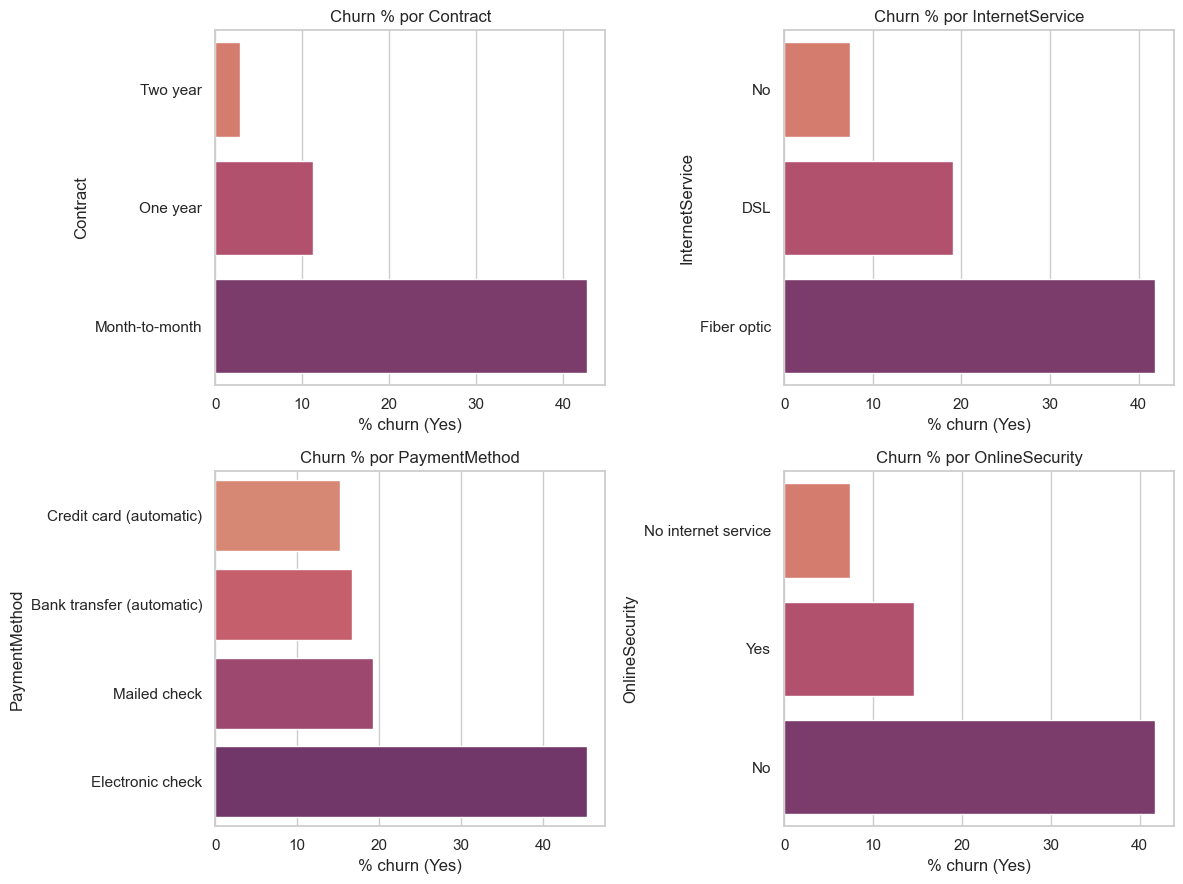

In [35]:
# Tasas de churn (%) — vista comparativa (misma lógica que la celda anterior)
plot_cols = ["Contract", "InternetService", "PaymentMethod", "OnlineSecurity"]
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, col in zip(axes.ravel(), plot_cols):
    s = churn_rate_by(col).sort_values(ascending=True)
    sns.barplot(x=s.values, y=s.index.astype(str), ax=ax, palette="flare")
    ax.set_title(f"Churn % por {col}")
    ax.set_xlabel("% churn (Yes)")
plt.tight_layout()
plt.show()


## 8. Variables numéricas vs Churn (Mann–Whitney)

Las distribuciones no suelen ser normales; se compara la ubicación de **No** vs **Yes** con **Mann–Whitney** (comparación de rangos). Complementa los **violinplots**: diferencias de mediana y forma entre clases.

### Interpretación esperada

- **`tenure`:** la mediana de quienes hacen churn suele ser **claramente menor** que la de quienes se quedan (menos tiempo en la empresa).
- **`MonthlyCharges`:** las medianas suelen diferir (paquetes y precios distintos entre churn y no churn).
- **`TotalCharges`:** también diferencia por la correlación con `tenure` y el nivel de facturación.

Si los p-valores son extremadamente bajos, se alinea con que estas variables serán útiles en modelado predictivo (no implica causalidad).


In [36]:
g0 = data.loc[data["Churn"] == "No", num_cols]
g1 = data.loc[data["Churn"] == "Yes", num_cols]

for c in num_cols:
    stat, p = mannwhitneyu(g0[c], g1[c], alternative="two-sided")
    print(f"{c}: estadístico={stat:.2f}, p={p:.2e} | mediana No={g0[c].median():.2f}, Yes={g1[c].median():.2f}")

tenure: estadístico=7154668.00, p=6.04e-211 | mediana No=38.00, Yes=10.00
MonthlyCharges: estadístico=3663498.50, p=8.47e-54 | mediana No=64.45, Yes=79.65
TotalCharges: estadístico=6288982.00, p=2.00e-84 | mediana No=1683.60, Yes=703.55


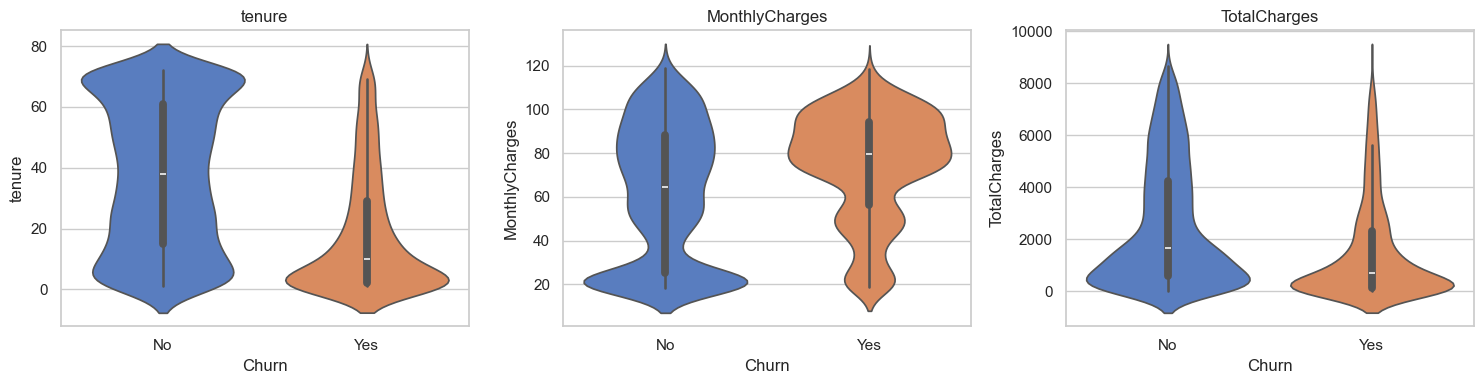

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, c in zip(axes, num_cols):
    sns.violinplot(data=data, x="Churn", y=c, order=["No", "Yes"], ax=ax, palette="muted")
    ax.set_title(c)
plt.tight_layout()
plt.show()

## 9. Matriz de correlación (numéricas + SeniorCitizen)

La correlación de Pearson mide **relación lineal** entre variables numéricas. Valores altos entre `MonthlyCharges` y `TotalCharges` son esperables (multicolinealidad); en regresión logística puede ser necesaria regularización o eliminar una de las dos.

### Interpretación

- Correlación moderada/alta entre cargos mensuales y totales: redundancia parcial.
- `SeniorCitizen` correlacionado de forma débil con el resto; su efecto sobre churn se ve mejor en el análisis categórico o en el modelo.


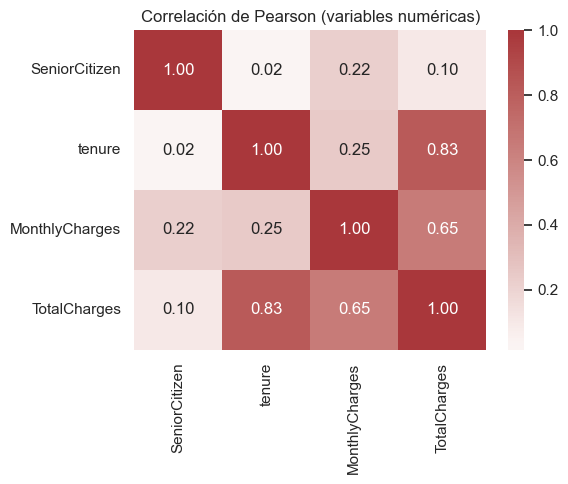

In [38]:
num_for_corr = data[["SeniorCitizen"] + num_cols].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(num_for_corr, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Correlación de Pearson (variables numéricas)")
plt.tight_layout()
plt.show()

## 10. Visualización multivariada — interacción Contract × InternetService

El mapa de calor muestra la **tasa de churn (%)** en cada cruce de segmentos (tipo de contrato × tipo de internet). Es una vista útil para **equipos comerciales**: identificar celdas de alto riesgo (retención focalizada).

### Interpretación

- La combinación **mes a mes + fibra** suele mostrar tasas de churn elevadas en comparación con contratos largos.
- Los contratos **a uno o dos años** actúan como ancla de retención (menor % de churn en la muestra).


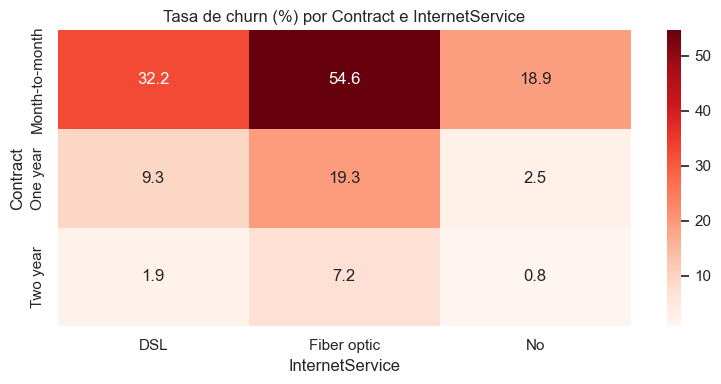

In [39]:
pivot = (
    data.assign(churn_yes=lambda d: (d["Churn"] == "Yes").astype(int))
    .groupby(["Contract", "InternetService"], observed=True)["churn_yes"]
    .mean()
    .unstack()
    * 100
)
plt.figure(figsize=(8, 4))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="Reds")
plt.title("Tasa de churn (%) por Contract e InternetService")
plt.tight_layout()
plt.show()

## 11. Ingeniería de características (propuestas para modelado)

Ideas documentadas para un **segundo sprint**, no obligatorias en el EDA inicial:

- **`avg_charge_per_tenure_month`:** proxy de tarifa media histórica; sensible a `tenure` pequeño (por eso se acotó la limpieza).
- **`tenure_group`:** cuartiles de antigüedad para capturar no linealidades y facilitar explicación a negocio.

### Interpretación del gráfico

El boxplot por cuartil de antigüedad y churn muestra si el “precio medio por mes de vida” difiere entre quienes se van y quienes no; puede orientar políticas de descuento por antigüedad.


In [40]:
feat = data.copy()
feat["avg_charge_per_tenure_month"] = np.where(
    feat["tenure"] > 0, feat["TotalCharges"] / feat["tenure"], np.nan
)
feat["tenure_group"] = pd.qcut(feat["tenure"], q=4, duplicates="drop")
feat[["tenure", "TotalCharges", "avg_charge_per_tenure_month", "tenure_group", "Churn"]].head()

,tenure,TotalCharges,avg_charge_per_tenure_month,tenure_group,Churn
0,1,29.85,29.850000,"(0.999, 9.0]",No
1,34,1889.50,55.573529,"(29.0, 55.0]",No
2,2,108.15,54.075000,"(0.999, 9.0]",Yes
3,45,1840.75,40.905556,"(29.0, 55.0]",No
4,2,151.65,75.825000,"(0.999, 9.0]",Yes


## 12. Síntesis ejecutiva y conclusiones de datos

### Hallazgos robustos (típicos en este dataset)

1. **Calidad:** `TotalCharges` requiere conversión; un pequeño subconjunto carece de valor coherente (suele alinearse con `tenure` bajo). La política de exclusión o imputación debe documentarse en producción.
2. **Objetivo:** prevalencia de **No churn** mayor que **Yes**; cualquier modelo debe compararse contra la clase mayoritaria y, idealmente, contra **coste de error** (falso negativo en churn = cliente perdido).
3. **Contrato:** `Month-to-month` concentra tasas de churn muy superiores a contratos largos; es el driver más legible para **acciones de retención** (descuentos al pasar a un año).
4. **Servicios / fibra / seguridad:** categorías como `InternetService` y add-ons de seguridad suelen mostrar fuerte asociación con churn (Chi²); interpretación de negocio: clientes con fibra y sin soporte pueden tener más incidencias percibidas.
5. **Numéricas:** `tenure` menor y `MonthlyCharges` distintos entre grupos respaldan la intuición de "clientes nuevos o caros relativamente más volátiles" según segmento; Mann–Whitney suele dar p-valores muy bajos.
6. **Correlación:** alta entre cargos mensuales y totales; en modelos lineales considerar regularización o eliminación de una o usar componentes.

### Limitaciones

- **Observacional:** asociación ≠ causalidad; intervenciones requieren experimentos (ofertas A/B) o datos longitudinales.
- **Snapshot:** no hay orden temporal explícito de eventos; riesgo de **fuga de información** si en el futuro se incorporan variables posteriores al churn.
- **Chi² / Mann–Whitney:** asumen muestras i.i.d.; clientes pueden tener estructura regional o de producto no observada.

### Roadmap hacia ML y negocio

- **Partición** estratificada por `Churn`; métricas: **ROC-AUC**, **recall** del churn, **matriz de costes**.
- **Modelos:** regresión logística con interpretabilidad, Random Forest para no linealidad, calibración de probabilidades para umbral según coste.
- **Operación:** monitorizar deriva de variables y tasa de churn mensual por cohorte `tenure`.

---

El pipeline anterior recorre el ciclo habitual de un EDA aplicado a negocio: auditoría y limpieza, definición del objetivo, distribuciones y asociaciones con el churn, matriz de correlación, segmentos multivariados (`Contract` × `InternetService`), propuestas de variables derivadas y cierre con limitaciones y roadmap hacia modelado. La etapa siguiente es el entrenamiento y la evaluación con métricas alineadas al coste del error.
